# 종합적인 Current skill지표 만들기 

In [13]:
import pandas as pd

# =========================
# LOAD
# =========================

riot = pd.read_csv(
    "./솔랭데이터/current_skill_scores.csv"
)

oracle = pd.read_csv(
    "./오라클데이터/current_skill_scores.csv"
)

# =========================
# 컬럼명 변경
# =========================

riot = riot.rename(
    columns={
        "CurrentSkill": "RiotSkill"
    }
)

oracle = oracle.rename(
    columns={
        "CurrentSkill": "OracleSkill"
    }
)

# =========================
# PATCH -> META GROUP
# =========================

def make_meta_group(patch):

    major, minor = str(patch).split(".")

    major = int(major)
    minor = int(minor)

    # =========================
    # 5패치 단위 메타 그룹
    # =========================

    meta_id = ((minor - 1) // 5) + 1

    return f"{major}_{meta_id}"

# =========================
# 메타 그룹 생성
# =========================

riot["meta_group"] = (
    riot["patch"]
    .apply(make_meta_group)
)

oracle["meta_group"] = (
    oracle["patch"]
    .apply(make_meta_group)
)

# =========================
# 필요한 컬럼만
# =========================

riot = riot[
    [
        "playername",
        "patch",
        "meta_group",
        "RiotSkill"
    ]
]

oracle = oracle[
    [
        "playername",
        "patch",
        "meta_group",
        "OracleSkill"
    ]
]

# =========================
# META GROUP 평균
# =========================

riot_grouped = (
    riot
    .groupby(
        ["playername", "meta_group"]
    )["RiotSkill"]
    .mean()
    .reset_index()
)

oracle_grouped = (
    oracle
    .groupby(
        ["playername", "meta_group"]
    )["OracleSkill"]
    .mean()
    .reset_index()
)

# =========================
# MERGE
# =========================

merged = pd.merge(
    riot_grouped,
    oracle_grouped,
    on=[
        "playername",
        "meta_group"
    ],
    how="inner"
)

# =========================
# Unified Skill
# =========================

merged["UnifiedSkill"] = (
    merged["RiotSkill"] * 0.5
    +
    merged["OracleSkill"] * 0.5
)

# =========================
# Skill Gap
# =========================

merged["SkillGap"] = (
    merged["RiotSkill"]
    -
    merged["OracleSkill"]
)

# =========================
# 결과 확인
# =========================

print("=" * 50)
print("MERGED SHAPE")
print(merged.shape)

print("=" * 50)
print("CORRELATION")
print(
    merged[
        ["RiotSkill", "OracleSkill"]
    ].corr()
)

print("=" * 50)
print("TOP UNIFIED SKILL")

display(
    merged
    .sort_values(
        "UnifiedSkill",
        ascending=False
    )
    .head(30)
)

print("=" * 50)
print("TOP SKILL GAP")

display(
    merged
    .sort_values(
        "SkillGap",
        ascending=False
    )
    .head(30)
)

MERGED SHAPE
(47, 6)
CORRELATION
             RiotSkill  OracleSkill
RiotSkill     1.000000     0.612463
OracleSkill   0.612463     1.000000
TOP UNIFIED SKILL


,playername,meta_group,RiotSkill,OracleSkill,UnifiedSkill,SkillGap
11,Chovy,15_4,84.388949,78.901555,81.645252,5.487394
13,Chovy,16_2,81.190668,78.163386,79.677027,3.027281
12,Chovy,16_1,69.714851,88.578686,79.146768,-18.863835
41,Zeka,14_4,65.441841,66.034289,65.738065,-0.592448
43,Zeka,16_2,56.807548,72.625939,64.716744,-15.818391
9,Chovy,15_2,48.708144,80.549248,64.628696,-31.841104
10,Chovy,15_3,55.274758,71.518918,63.396838,-16.244160
26,ShowMaker,14_3,61.068445,64.032265,62.550355,-2.963820
30,ShowMaker,16_1,50.366069,69.908204,60.137137,-19.542136
17,Faker,16_1,51.920110,68.203191,60.061650,-16.283082


TOP SKILL GAP


,playername,meta_group,RiotSkill,OracleSkill,UnifiedSkill,SkillGap
27,ShowMaker,14_4,65.409133,43.251168,54.330151,22.157965
21,Loki,16_2,58.660529,37.462798,48.061664,21.197731
28,ShowMaker,15_1,53.844062,35.152091,44.498076,18.691970
33,Ucal,15_2,51.388394,36.914735,44.151565,14.473658
44,kyeahoo,15_1,39.356989,27.857745,33.607367,11.499244
11,Chovy,15_4,84.388949,78.901555,81.645252,5.487394
31,ShowMaker,16_2,45.668814,40.782420,43.225617,4.886393
13,Chovy,16_2,81.190668,78.163386,79.677027,3.027281
0,Bdd,14_3,51.916536,51.068576,51.492556,0.847960
19,Fisher,14_3,40.083518,40.053124,40.068321,0.030394


In [ ]:
merged = pd.merge(
    riot,
    oracle,
    on=[
        "playername",
        "meta_group"
    ],
    how="inner",
    suffixes=("_riot", "_oracle")
)
# 거리가 가까운 패치 끼리 묶은거임 
merged

,playername,patch_riot,meta_group,RiotSkill,patch_oracle,OracleSkill
0,Chovy,16.06,16_2,100.000000,16.08,80.339639
1,Chovy,16.06,16_2,100.000000,16.07,78.621630
2,Chovy,16.06,16_2,100.000000,16.06,75.528889
3,Chovy,15.16,15_4,98.766957,15.16,88.923394
4,Chovy,15.16,15_4,98.766957,15.17,68.879717
...,...,...,...,...,...,...
438,Bdd,15.11,15_3,12.574634,15.14,35.795531
439,Bdd,15.11,15_3,12.574634,15.15,31.820788
440,Clozer,16.08,16_2,8.006108,16.06,51.748098
441,Clozer,16.08,16_2,8.006108,16.08,31.006801


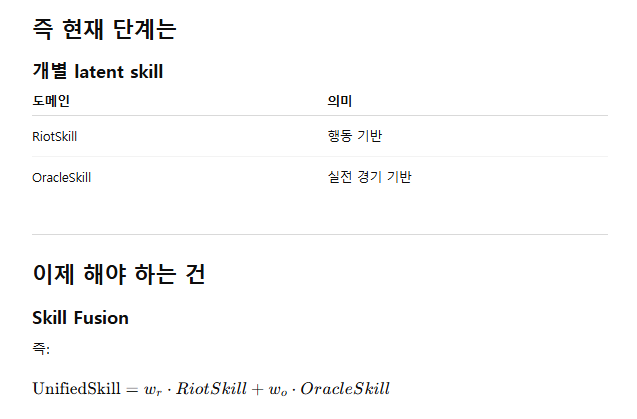

* 이런식으로 계산식 적용 ( Current score 계산식 )

In [19]:
print(
    merged[
        ["RiotSkill", "OracleSkill"]
    ].corr()
)

             RiotSkill  OracleSkill
RiotSkill     1.000000     0.426948
OracleSkill   0.426948     1.000000


In [20]:
merged["UnifiedSkill"] = (
    merged["RiotSkill"] * 0.5
    +
    merged["OracleSkill"] * 0.5
)

### 최종 score 출력 


In [22]:
merged.sort_values(
    "UnifiedSkill", ascending=False
).head(30)

,playername,patch_riot,meta_group,RiotSkill,patch_oracle,OracleSkill,UnifiedSkill
3,Chovy,15.16,15_4,98.766957,15.16,88.923394,93.845175
0,Chovy,16.06,16_2,100.000000,16.08,80.339639,90.169819
1,Chovy,16.06,16_2,100.000000,16.07,78.621630,89.310815
2,Chovy,16.06,16_2,100.000000,16.06,75.528889,87.764445
5,Chovy,15.19,15_4,82.444188,15.16,88.923394,85.683791
23,Chovy,16.04,16_1,71.152582,16.01,96.744716,83.948649
26,Chovy,16.03,16_1,70.925589,16.01,96.744716,83.835152
4,Chovy,15.16,15_4,98.766957,15.17,68.879717,83.823337
29,Chovy,16.02,16_1,68.854780,16.01,96.744716,82.799748
32,Chovy,16.01,16_1,67.926451,16.01,96.744716,82.335584


* 이렇게 보니까 정직하게 나오긴하네 

In [24]:
# 분석다한거 저장 
merged.to_csv(
    "./current_skill_analysis.csv",
    index=False
)